In [6]:
import pickle
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import polychrom
import seaborn as sns
import cooltools

from polychrom import polymerutils
from polychrom import forces,forcekits
from polychrom.simulation import Simulation
from polychrom.starting_conformations import grow_cubic
from polychrom.hdf5_format import HDF5Reporter, list_URIs, load_URI, load_hdf5_file
from polychrom.contactmaps import monomerResolutionContactMap, monomerResolutionContactMapSubchains, binnedContactMap


import simtk.openmm 
import shutil

import time
import warnings
import h5py 
import glob
from multiprocessing import Pool 


/home/leonardo/miniconda3/envs/polychrom/lib/python3.7/site-packages/cooltools/lib/numutils.py:11: FutureWarning: The `cooler.tools` module is deprecated in v0.9 and will be removed in v0.10. Use `cooler.parallel` instead.
  from ._numutils import (
/home/leonardo/miniconda3/envs/polychrom/lib/python3.7/site-packages/cooltools/api/expected.py:14: FutureWarning: The `cooler.tools` module is deprecated in v0.9 and will be removed in v0.10. Use `cooler.parallel` instead.
  from cooler.tools import partition


to upgrade openmm, run --->  conda install -c conda-forge openmm
Ideally in a new conda environment


/home/leonardo/miniconda3/envs/polychrom/lib/python3.7/site-packages/polychrom/simulation.py:116: UserWarning: 
  f"\n WARNING: you have OpenMM {ver_cur}; {VER_LATEST} is the latest as of {VER_DATE}, "


### 0) Utils functions

#####  trajectory functions

In [3]:
class leg(object):
    def __init__(self, pos, attrs={"stalled":False, "CTCF":False}):
        """
        A leg has two important attribues: pos (positions) and attrs (a custom list of attributes)
        """
        self.pos = pos
        self.attrs = dict(attrs)

class cohesin(object):
    """
    A cohesin class provides fast access to attributes and positions 
    
    
    cohesin.left is a left leg of cohesin, cohesin.right is a right leg
    cohesin[-1] is also a left leg and cohesin[1] is a right leg         
    
    Also, cohesin.any("myattr") is True if myattr==True in at least one leg
    cohesin.all("myattr") is if myattr=True in both legs
    """
    def __init__(self, leg1, leg2):
        self.left = leg1
        self.right = leg2
   
    def any(self, attr):
        return self.left.attrs[attr] or self.right.attrs[attr]
    
    def all(self, attr):
        return self.left.attrs[attr] and self.right.attrs[attr]    
    
    def __getitem__(self, item):
        if item == -1:
            return self.left
        elif item == 1:
            return self.right 
        else:
            raise ValueError()
        

def unloadProb(cohesin, args):
    """
    Defines unload probability based on a state of cohesin 
    """
    if cohesin.any("stalled"):
        # if one side is stalled, we have different unloading probability 
        # Note that here we define stalled cohesins as those stalled not at CTCFs 
        return 1 / args["LIFETIME_STALLED"]
    # otherwise we are just simply unloading 
    return 1 / args["LIFETIME"]    
    


def loadOne(cohesins, occupied, args): 
    """
    A function to load one cohesin 
    """
    while True:
        a = np.random.randint(args["N"])
        if (occupied[a] == 0) and (occupied[a+1] == 0):
            occupied[a] = 1
            occupied[a+1] = 1 
            cohesins.append(cohesin(leg(a), leg(a+1)))
            break


def capture(cohesin, occupied, args):
    """
    We are describing CTCF capture here. 
    This function is specific to this particular project, and 
    users are encouraged to write functions like this 
    
    Note the for-loop over left/right sites below, and using cohesin[side] 
    to get left/right leg. 
    
    Also note how I made ctcfCapture a dict with -1 coding for left side, and 1 for right side 
    and ctcfCapture are dicts as well: keys are locations, and values are probabilities of capture
    """    
    for side in [1, -1]:
        # get probability of capture or otherwise it is 0 
        if np.random.random() < args["ctcfCapture"][side].get(cohesin[side].pos, 0):  
            cohesin[side].attrs["CTCF"] = True  # captured a cohesin at CTCF     
    return cohesin 


def release(cohesin, occupied, args):
    
    """
    AN opposite to capture - releasing cohesins from CTCF 
    """
    
    if not cohesin.any("CTCF"):
        return cohesin  # no CTCF: no release necessary 
        
    # attempting to release either side 
    for side in [-1, 1]: 
        if (np.random.random() < args["ctcfRelease"][side].get(cohesin[side].pos, 0)) and (cohesin[side].attrs["CTCF"]):
            cohesin[side].attrs["CTCF"] = False 
    return cohesin 


def translocate(cohesins, occupied, args):
    """
    This function describes everything that happens with cohesins - 
    loading/unloading them and stalling against each other 
    
    It relies on the functions defined above: unload probability, capture/release. 
    """
    # first we try to unload cohesins and free the matching occupied sites 
    for i in range(len(cohesins)):
        prob = unloadProb(cohesins[i], args)
        if np.random.random() < prob:
            occupied[cohesins[i].left.pos] = 0 
            occupied[cohesins[i].right.pos] = 0 
            del cohesins[i]
            loadOne(cohesins, occupied, args)
    
    # then we try to capture and release them by CTCF sites 
    for i in range(len(cohesins)):
        cohesins[i] = capture(cohesins[i], occupied, args)
        cohesins[i] = release(cohesins[i], occupied, args)
    
    # finally we translocate, and mark stalled cohesins because 
    # the unloadProb needs this 
    for i in range(len(cohesins)):
        cohesin = cohesins[i] 
        for leg in [-1,1]: 
            if not cohesin[leg].attrs["CTCF"]: 
                # cohesins that are not at CTCFs and cannot move are labeled as stalled 
                if occupied[cohesin[leg].pos  + leg] != 0:
                    cohesin[leg].attrs["stalled"] = True
                else:
                    cohesin[leg].attrs["stalled"] = False 
                    occupied[cohesin[leg].pos] = 0
                    occupied[cohesin[leg].pos + leg] = 1
                    cohesin[leg].pos += leg        
        cohesins[i] = cohesin
        
def color(cohesins, args):
    "A helper function that converts a list of cohesins to an array colored by cohesin state"    
    def state(attrs):
        if attrs["stalled"]:
            return 2
        if attrs["CTCF"]:
            return 3
        return 1
    ar = np.zeros(args["N"])
    for i in cohesins:
        ar[i.left.pos] = state(i.left.attrs)
        ar[i.right.pos] = state(i.right.attrs)  
    return ar 


#####  Extrusion functions

In [4]:
def make_ab_labels(n_monomers, pattern_length, pattern):
    """Create alternating labels 0=A and 1=B and repeat them to length N."""

    if sum(pattern) != pattern_length:
        raise ValueError(
            "PATTERN sums to {}, but PATTERN_LENGTH is {}.".format(
                sum(pattern), pattern_length
            )
        )
    if n_monomers % pattern_length != 0:
        raise ValueError(
            "N={} is not divisible by PATTERN_LENGTH={}.".format(
                n_monomers, pattern_length
            )
        )

    one_pattern = np.concatenate(
        [
            np.full(block_length, block_index % 2, dtype=np.int32)
            for block_index, block_length in enumerate(pattern)
        ]
    )
    labels = np.tile(one_pattern, n_monomers // pattern_length)

    if len(labels) != n_monomers:
        raise RuntimeError("Incorrect number of A/B labels generated.")

    return labels


def get_folder(aa_strength, bb_strength):
    """Return the shared LEF-input/polymer-output folder name."""

    return "trajectory_cp{}_rp{}_AA{}_BB{}_large_comp_low_LIFETIME_lower".format(
        CP,
        RP,
        aa_strength,
        bb_strength,
    )


def run_simulation(folder, aa_strength, bb_strength):
    """Generate loadable blocks_*.h5 trajectory files in ``folder``."""

    try:
        bondUpdater
    except NameError:
        raise NameError(
            "bondUpdater is not defined. Run its definition in the notebook "
            "or import it before running this script."
        )

    lef_path = os.path.join(folder, "LEFPositions.h5")
    if not os.path.isfile(lef_path):
        raise FileNotFoundError(
            "Cannot find {!r}. Generate LEFPositions.h5 first.".format(
                lef_path
            )
        )

    with h5py.File(lef_path, mode="r") as lef_file:
        n_monomers = int(lef_file.attrs["N"])
        n_lefs = int(lef_file.attrs["LEFNum"])
        lef_positions = lef_file["positions"]
        n_frames = int(lef_positions.shape[0])

        if n_monomers != TOTAL_MONOMERS:
            raise ValueError(
                "LEFPositions.h5 contains N={}, but TOTAL_MONOMERS={}.".format(
                    n_monomers, TOTAL_MONOMERS
                )
            )
        if n_frames % RESTART_EVERY_BLOCKS != 0:
            raise ValueError(
                "Nframes must be divisible by RESTART_EVERY_BLOCKS."
            )
        if RESTART_EVERY_BLOCKS % SAVE_EVERY_BLOCKS != 0:
            raise ValueError(
                "RESTART_EVERY_BLOCKS must be divisible by SAVE_EVERY_BLOCKS."
            )

        n_segments = n_frames // RESTART_EVERY_BLOCKS
        box_size = (n_monomers / DENSITY) ** (1.0 / 3.0)
        data = grow_cubic(n_monomers, int(box_size) - 2)

        monomer_types = make_ab_labels(
            n_monomers,
            PATTERN_LENGTH,
            PATTERN,
        )
        interaction_matrix = np.array(
            [
                [aa_strength, AB_STRENGTH],
                [AB_STRENGTH, bb_strength],
            ],
            dtype=float,
        )

        print("Output folder:", os.path.abspath(folder))
        print("Monomers:", n_monomers)
        print("LEFs:", n_lefs)
        print("LEF frames:", n_frames)
        print("Simulation segments:", n_segments)
        print("A monomers:", int(np.sum(monomer_types == 0)))
        print("B monomers:", int(np.sum(monomer_types == 1)))
        print("Interaction matrix:\n", interaction_matrix)

        milker = bondUpdater(lef_positions)

        # blocks_only=True is appropriate here because list_URIs reads the
        # blocks_*.h5 conformation files, not LEFPositions.h5 or force metadata.
        reporter = HDF5Reporter(
            folder=folder,
            max_data_length=REPORTER_MAX_DATA_LENGTH,
            overwrite=True,
            blocks_only=True,
        )

        start_time = time.time()

        try:
            for iteration in range(n_segments):
                print(
                    "Simulation segment {}/{}".format(
                        iteration + 1,
                        n_segments,
                    )
                )

                simulation = Simulation(
                    platform="cuda",
                    integrator="variableLangevin",
                    error_tol=0.01,
                    GPU="0",
                    collision_rate=0.03,
                    N=n_monomers,
                    reporters=[reporter],
                    PBCbox=[box_size, box_size, box_size],
                    precision="mixed",
                )
                simulation.set_data(data)

                # heteropolymer_SSW includes excluded-volume repulsion and
                # type-specific attraction. Do not also add polynomial_repulsive.
                simulation.add_force(
                    forcekits.polymer_chains(
                        simulation,
                        chains=[(0, None, False)],
                        bond_force_func=forces.harmonic_bonds,
                        bond_force_kwargs={
                            "bondLength": 1.0,
                            "bondWiggleDistance": 0.1,
                        },
                        angle_force_func=forces.angle_force,
                        angle_force_kwargs={"k": 1.5},
                        nonbonded_force_func=forces.heteropolymer_SSW,
                        nonbonded_force_kwargs={
                            "interactionMatrix": interaction_matrix,
                            "monomerTypes": monomer_types,
                            "extraHardParticlesIdxs": [],
                            "repulsionEnergy": 3.0,
                            "repulsionRadius": 1.0,
                            "attractionEnergy": 0.0,
                            "attractionRadius": 1.5,
                            "selectiveRepulsionEnergy": 0.0,
                            "selectiveAttractionEnergy": 1.0,
                            "keepVanishingInteractions": False,
                        },
                        except_bonds=True,
                    )
                )

                bond_k = (
                    simulation.kbondScalingFactor
                    / SMC_BOND_WIGGLE_DISTANCE**2
                )
                bond_length = SMC_BOND_DISTANCE * simulation.length_scale

                active_parameters = {
                    "length": bond_length,
                    "k": bond_k,
                }
                inactive_parameters = {
                    "length": bond_length,
                    "k": 0,
                }

                milker.setParams(active_parameters, inactive_parameters)
                milker.setup(
                    bondForce=simulation.force_dict["harmonic_bonds"],
                    blocks=RESTART_EVERY_BLOCKS,
                )

                if iteration == 0:
                    simulation.local_energy_minimization()
                else:
                    simulation._apply_forces()

                for block_index in range(RESTART_EVERY_BLOCKS):
                    should_save = (
                        block_index % SAVE_EVERY_BLOCKS
                        == SAVE_EVERY_BLOCKS - 1
                    )

                    if should_save:
                        # do_block reports this conformation to HDF5Reporter.
                        simulation.do_block(
                            steps=MD_STEPS_PER_EXTRUSION_STEP
                        )
                    else:
                        simulation.integrator.step(
                            MD_STEPS_PER_EXTRUSION_STEP
                        )

                    if block_index < RESTART_EVERY_BLOCKS - 1:
                        milker.step(simulation.context)

                # Carry final coordinates into the next OpenMM context.
                data = simulation.get_data()
                del simulation
                time.sleep(0.2)

        finally:
            # Flush conformations still buffered in memory.
            reporter.dump_data()

        elapsed = time.time() - start_time
        print("Simulation completed in {:.2f} seconds".format(elapsed))

    block_files = sorted(
        glob.glob(os.path.join(folder, "blocks_*.h5"))
    )
    if not block_files:
        raise RuntimeError(
            "The simulation ended without creating blocks_*.h5 files in {}."
            .format(os.path.abspath(folder))
        )

    print("Trajectory files written:", len(block_files))
    for filename in block_files[:5]:
        print("  ", filename)
    if len(block_files) > 5:
        print("  ...")


def load_saved_trajectory(folder):
    """List saved URIs and load the first conformation."""

    print("Loading trajectory from:", os.path.abspath(folder))

    block_files = sorted(
        glob.glob(os.path.join(folder, "blocks_*.h5"))
    )
    if not block_files:
        raise FileNotFoundError(
            "No blocks_*.h5 files were found in {}. ".format(
                os.path.abspath(folder)
            )
            + "LEFPositions.h5 is an input trajectory and is not returned by "
            + "list_URIs()."
        )

    # list_URIs returns one URI per saved conformation.
    uris = list_URIs(folder)
    print("Saved conformations:", len(uris))
    print("First URI:", uris[0])
    print("Last URI:", uris[-1])

    # load_URI loads one conformation dictionary.
    first_frame = load_URI(uris[0])
    first_positions = first_frame["pos"]

    print("First-frame keys:", sorted(first_frame.keys()))
    print("First-frame coordinate shape:", first_positions.shape)

    return uris, first_frame


def iter_saved_positions(uris):
    """Iterate over coordinates without loading the full trajectory into RAM."""

    for uri in uris:
        yield load_URI(uri)["pos"]


##### parameters for simulations

In [12]:
# =============================================================================
# USER PARAMETERS
# =============================================================================

TOTAL_MONOMERS = 30_000
PATTERN_LENGTH = 3_000
M = int(TOTAL_MONOMERS/PATTERN_LENGTH)

# TAD pattern (mean tad size 960 kb)
TADs =  [100,150,280,370,450,510,610,730,810,900,1050,1200,1300,1420,1500,1580,1600,1800,1840,1900,2090,2140,2200,2340,2410,2500,2650,2710,2800,2920]



# Alternating A/B block lengths within one 3,000-monomer pattern.
PATTERN  = [
    400, 350, 500, 250,
    450, 300, 400, 350
]

CP = 0.85 # capture probability for loop extruders
RP = 0.04 # release probability of loop extruders
LIFETIME = 50 # lifetime of extruders
SEPARATION = 130 # density of extruders
trajectoryLength = 10000 # number of steps of loop-extruder (LEF/cohesin) dynamics are simulated and stored

# Compartment-specific attractions in approximately kT.
AA_STRENGTH = 0.3 # strength of homotypic A-A compartment interactions
BB_STRENGTH = 0.4 # strength of homotypic B-B compartment interactions
AB_STRENGTH = 0.00

# Molecular-dynamics parameters.
DENSITY = 0.1
MD_STEPS_PER_EXTRUSION_STEP = 750
SAVE_EVERY_BLOCKS = 10
RESTART_EVERY_BLOCKS = 100

# Ten conformations are produced per restart segment. Using ten here ensures
# that every completed segment is flushed to a blocks_*.h5 file.
REPORTER_MAX_DATA_LENGTH = 10

# SMC bond parameters.
SMC_BOND_WIGGLE_DISTANCE = 0.2
SMC_BOND_DISTANCE = 0.5

# Set to False after generating the trajectory if you only want to load the
# existing blocks_*.h5 files.
RUN_SIMULATION = True

### 1) Trajectory

In [ ]:
for comp in [[AA_STRENGTH,BB_STRENGTH]]:
    print(comp)
            
    LEFNum = TOTAL_MONOMERS // SEPARATION 
   
    ctcfLeftRelease = {}
    ctcfRightRelease = {}
    ctcfLeftCapture = {}
    ctcfRightCapture = {}

    for i in range(M):
        for tad in TADs:
            pos = i * PATTERN_LENGTH + tad 
            ctcfLeftCapture[pos] = CP  # 90% capture probability 
            ctcfLeftRelease[pos] = RP  # hold it for ~300 blocks on average
            ctcfRightCapture[pos] = CP
            ctcfRightRelease[pos] = RP

    args = {}
    args["ctcfRelease"] = {-1:ctcfLeftRelease, 1:ctcfRightRelease}
    args["ctcfCapture"] = {-1:ctcfLeftCapture, 1:ctcfRightCapture}        
    args["N"] = N 
    args["LIFETIME"] = LIFETIME
    args["LIFETIME_STALLED"] = LIFETIME  # no change in lifetime when stalled 
    compA=comp[0]
    compB=comp[1]
    folder=f'trajectory_cp{CP}_rp{RP}_AA{compA}_BB{compB}'
    if not os.path.exists(folder):
        os.mkdir(folder)


    occupied = np.zeros(N)
    occupied[0] = 1
    occupied[-1] = 1 
    cohesins = []

    for i in range(LEFNum):
        loadOne(cohesins,occupied, args)

    with h5py.File(f'{folder}/LEFPositions.h5', mode='w') as myfile:

        dset = myfile.create_dataset("positions", 
                                     shape=(trajectoryLength, LEFNum, 2), 
                                     dtype=np.int32, 
                                     compression="gzip")
        steps = 50    # saving in 50 chunks because the whole trajectory may be large 
        bins = np.linspace(0, trajectoryLength, steps, dtype=int) # chunks boundaries 
        for st,end in zip(bins[:-1], bins[1:]):
            cur = []
            for i in range(st, end):
                translocate(cohesins, occupied, args)  # actual step of LEF dynamics 
                positions = [(cohesin.left.pos, cohesin.right.pos) for cohesin in cohesins]
                cur.append(positions)  # appending current positions to an array 
            cur = np.array(cur)  # when we finished a block of positions, save it to HDF5 
            dset[st:end] = cur
        myfile.attrs["N"] = N
        myfile.attrs["LEFNum"] = LEFNum

### 2) Extrusion 3D

In [ ]:
if __name__ == "__main__":
    output_folder = get_folder(AA_STRENGTH, BB_STRENGTH)

    if RUN_SIMULATION:
        run_simulation(
            folder=output_folder,
            aa_strength=AA_STRENGTH,
            bb_strength=BB_STRENGTH,
        )

    URIs, first_conformation = load_saved_trajectory(output_folder)
    first_coordinates = first_conformation["pos"]

### 3) visualization of the model

In [8]:
URIs = list_URIs(f"trajectory_cp{CP}_rp{RP}_AA{AA_strength}_BB{BB_strength}/")
URIs=URIs[:999]


starts = list(range(0, 29000, 3000))


hmap = monomerResolutionContactMapSubchains(filenames=URIs,  mapStarts=starts, mapN=3000, cutoff=6,
                        n=20, loadFunction=lambda x:load_URI(x)["pos"])




/home/leonardo/miniconda3/envs/polychrom/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log2
  


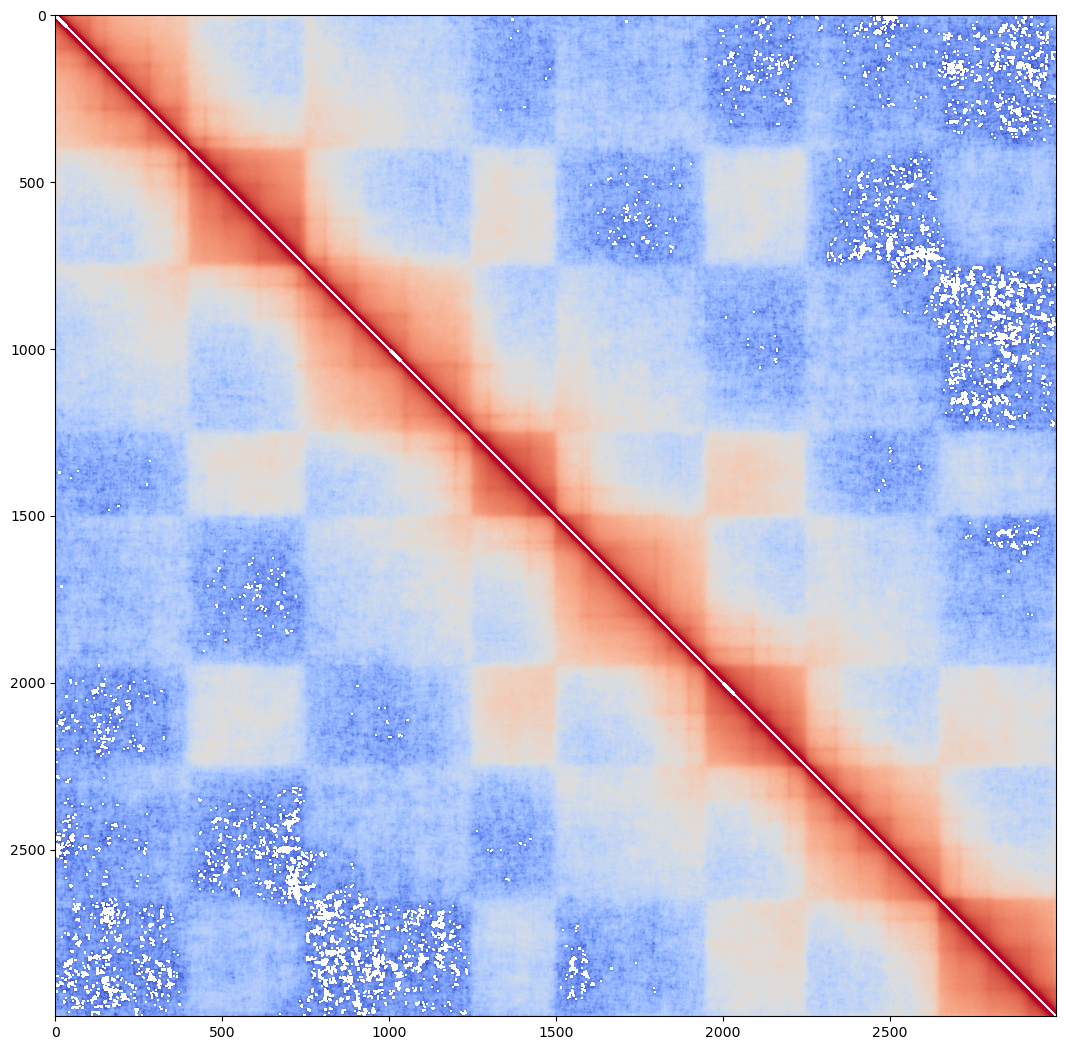

In [9]:
plt.figure(figsize=(13,13))
plt.imshow(np.log2(hmap), cmap='coolwarm',vmin=0,vmax=np.percentile(np.log2(hmap.flatten()),99))

In [ ]:
plt.figure(figsize=(13,13))
plt.imshow(np.log(cooltools.numutils.observed_over_expected(hmap)[0]), cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f'OE cp={CP} rp={RP} AA={AA_strength} BB={BB_strength}')

/home/leonardo/miniconda3/envs/polychrom/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log
  


NameError: name 'AA_strength' is not defined